# 03. Adjacency, coordination and the aGCN catalysis model

**Goal.** Build the adjacency matrix from R_cut, derive CN and the atop generalised coordination number (aGCN), and use the aGCN site distribution to estimate oxygen-reduction mass activity.

**You need.** Tutorials 01–02.

Sapphire is a post-processing environment for metallic nanoparticle (MNP) simulations. This series
builds up from a single structure to full molecular-dynamics trajectories; every notebook runs
offline on data bundled with the package and finishes in well under a minute.


In [1]:
import numpy as np, matplotlib.pyplot as plt
from ase.cluster import Icosahedron
from Sapphire.Post_Process import Adjacent, DistFuncs, Kernels, Mass_Activity as MA

au = Icosahedron("Pt", noshells=6, latticeconstant=3.92)     # platinum this time: the ORR model is for Pt
pos = au.positions
dist = DistFuncs.Euc_Dist(pos)
r_cut = Kernels.Gauss(dist, 0.05).ReturnRCut()
A = Adjacent.Adjacency_Matrix(Positions=pos, Distances=dist, R_Cut=r_cut)   # standalone: Type defaults to 'Full'
adj = A.ReturnAdj()                                                        # scipy sparse (N x N)
print("R_cut = %.3f Å;" % r_cut, "bonds:", adj.sum() // 2)

R_cut = 3.075 Å; bonds: 2910


## 3.1 From adjacency to CN and aGCN

Row sums of the adjacency matrix are the coordination numbers. The **atop GCN** of atom *i* is
Σ_j∈N(i) CN(j) / 12 (Calle-Vallejo et al., *Science* 2015). Sapphire computes it inside `Process`
(`Adjacent.agcn_generator`); here we do it in two numpy lines to see what it is.

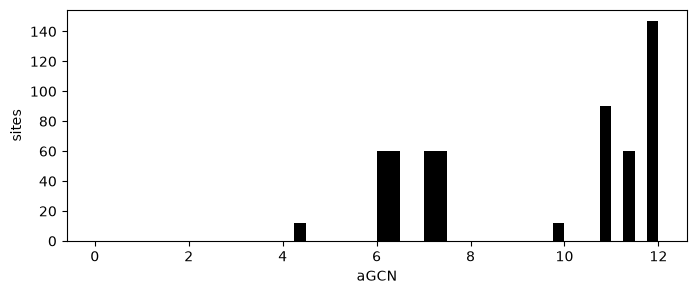

vertices     CN=6  aGCN=[4.33]
edges        CN=8  aGCN=[6.   6.33]
(111) facets CN=9  aGCN=[7.17 7.33]
bulk         CN=12  aGCN=[ 9.83 10.83 11.25 12.  ]


In [2]:
D = np.asarray(adj.todense())
cn = D.sum(1)
agcn = D @ cn / 12.0
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(agcn, bins=np.arange(0, 12.25, 0.25), color="k"); ax.set_xlabel("aGCN"); ax.set_ylabel("sites"); plt.show()
for name, mask in [("vertices", cn == 6), ("edges", cn == 8), ("(111) facets", cn == 9), ("bulk", cn == 12)]:
    print(f"{name:12s} CN={cn[mask][0] if mask.any() else '-'}  aGCN={np.unique(np.round(agcn[mask],2))}")

## 3.2 Which sites are catalytically active?

For the oxygen reduction reaction on Pt the activity of a site is a **volcano** in its GCN
(Rück et al. 2018; Rossi, Asara & Baletto 2019 — the model in `Sapphire.Post_Process.Mass_Activity`):

$$A_l(\alpha)=e^{3.14\alpha-23.40}\ (\alpha\le\alpha^*),\qquad A_r(\alpha)=e^{-4.96\alpha+42.18}\ (\alpha>\alpha^*)$$

relative to a Pt(111) terrace site (GCN 7.5). Slightly *concave* sites (GCN ≈ 8.1–8.3) bind OH a
little weaker than the terrace and sit at the apex; vertices (GCN < 6) do not count.

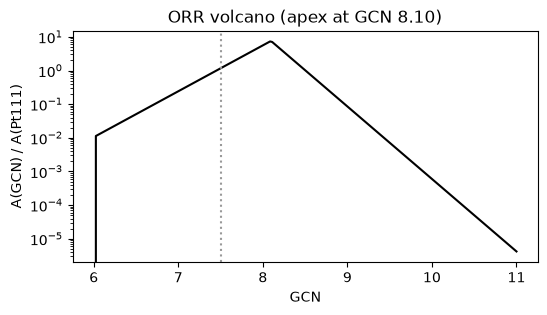

In [3]:
g = np.linspace(6, 11, 200)
plt.figure(figsize=(6, 3)); plt.semilogy(g, MA.site_activity(g), "k"); plt.axvline(7.5, color="0.6", ls=":")
plt.xlabel("GCN"); plt.ylabel("A(GCN) / A(Pt111)"); plt.title("ORR volcano (apex at GCN %.2f)" % MA.GCN_APEX); plt.show()

## 3.3 Mass activity of a whole particle

Summing site activities gives the particle's current relative to one Pt(111) site; dividing by the
particle mass (species-weighted, so alloys work) gives the **mass activity** in A mg⁻¹
(Eq. 7 of Rossi et al.: 4.107·Σ A / N for pure Pt).

In [4]:
ma = MA.mass_activity(agcn, symbols=au.get_chemical_symbols())
print("Pt561 icosahedron: mass activity %.3f A/mg" % ma)
print("  sites with GCN > 6:", int((agcn > 6).sum()), " of", len(agcn))
for n in (3, 4, 5, 6, 7):
    c = Icosahedron("Pt", noshells=n, latticeconstant=3.92)
    d = DistFuncs.Euc_Dist(c.positions); rc = Kernels.Gauss(d, 0.05).ReturnRCut()
    Dn = np.asarray(Adjacent.Adjacency_Matrix(Positions=c.positions, Distances=d, R_Cut=rc).ReturnAdj().todense())
    print(f"  {len(c):5d} atoms -> MA = {MA.mass_activity(Dn @ Dn.sum(1) / 12, symbols=c.get_chemical_symbols()):.3f} A/mg")

Pt561 icosahedron: mass activity 0.495 A/mg
  sites with GCN > 6: 489  of 561
     55 atoms -> MA = 0.001 A/mg


    147 atoms -> MA = 0.136 A/mg
    309 atoms -> MA = 0.337 A/mg


    561 atoms -> MA = 0.495 A/mg


    923 atoms -> MA = 0.592 A/mg


Mass activity falls with size because the active surface fraction falls — the classic argument
for small particles — while very small clusters lose activity again because their surface is all
low-GCN vertices and edges.

## 3.4 Try it

* Replace the icosahedron by `Octahedron("Pt", length=7, cutoff=2)`: (111) facets dominate — does MA rise?
* Rattle the cluster (`rattle(0.1)`) and recompute: thermal disorder creates concave sites near the apex.
* In Tutorial 05 the same quantity is computed frame by frame along an MD trajectory.

**Next:** *04 — Common-neighbour analysis: signatures, patterns and classification.*